# **C07 - Griegas por diferencias finitas**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 8 de septiembre de 2026

---

**Ejercicio:** calcular las derivadas parciales de la función de valuación $V$ respecto de cada una de sus variables y graficarlas sobre los rangos de tabulación indicados en clase.

El análisis de sensibilidad previo mostró hacia dónde se mueve el precio de una opción cuando cambia un parámetro, pero no con qué rapidez lo hace en cada punto, y esa velocidad de cambio es justamente la derivada parcial que aquí se calcula, de modo que las griegas convierten la lectura cualitativa de las curvas en una medida puntual de exposición.

## Índice de contenidos

1. Sección 1 — Definición de las griegas y método de cálculo
2. Sección 2 — Delta y gamma frente al precio del activo
3. Sección 3 — Vega frente a la volatilidad
4. Sección 4 — Theta frente al tiempo
5. Sección 5 — Rho frente a la tasa
6. Sección 6 — Tabla de efectos
7. Sección 7 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## 1. Definición de las griegas y método de cálculo

Cada griega es la derivada parcial del valor de la opción respecto de una de las variables que la determinan, de modo que delta mide la tasa de cambio frente al precio del activo, gamma la tasa de cambio de la propia delta, vega la respuesta ante la volatilidad, theta la respuesta ante el plazo y rho la respuesta ante la tasa libre de riesgo.

$$\Delta = \frac{\partial V}{\partial S}, \qquad \Gamma = \frac{\partial \Delta}{\partial S} = \frac{\partial^2 V}{\partial S^2}, \qquad \nu = \frac{\partial V}{\partial \sigma}, \qquad \Theta = \frac{\partial V}{\partial T}, \qquad \rho = \frac{\partial V}{\partial r}$$

Las derivadas no se toman de la forma cerrada sino que se calculan de manera manual sobre la tabulación, evaluando la función en una malla y sustituyendo la derivada por el cociente de diferencias entre dos puntos consecutivos, con lo cual el procedimiento es idéntico para las cinco griegas y sólo cambia la variable que se recorre.

$$\frac{\partial V}{\partial x} \approx \frac{V_{k+1} - V_k}{x_{k+1} - x_k}$$

La función $V$ se evalúa con la fórmula de Black-Scholes en lugar de la simulación Monte Carlo, ya que el estimador simulado es una función lineal por tramos del precio inicial cuando se reutiliza la misma muestra, y aunque eso permite aproximar delta sin problema, la segunda derivada de una función lineal por tramos carece de sentido y gamma resultaría inservible.

In [2]:
S_0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1

## 2. Delta y gamma frente al precio del activo

El precio del activo recorre el intervalo de 80 a 120 pesos con 10,001 puntos, número impar elegido a propósito para que el valor base de 100 pesos caiga exactamente sobre la malla y la comparación contra la fórmula analítica no dependa de una interpolación.

In [3]:
precios = np.linspace(80, 120, 10001)

valores_call = []
valores_put = []

for precio in precios:
    d1 = (np.log(precio / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    valores_call.append(precio * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    valores_put.append(K * np.exp(-r * T) * norm.cdf(-d2) - precio * norm.cdf(-d1))

delta_call = []
delta_put = []

for k in range(len(precios) - 1):
    paso = precios[k + 1] - precios[k]
    delta_call.append((valores_call[k + 1] - valores_call[k]) / paso)
    delta_put.append((valores_put[k + 1] - valores_put[k]) / paso)

gamma_call = []
gamma_put = []

for k in range(len(delta_call) - 1):
    paso = precios[k + 1] - precios[k]
    gamma_call.append((delta_call[k + 1] - delta_call[k]) / paso)
    gamma_put.append((delta_put[k + 1] - delta_put[k]) / paso)

delta_call = np.array(delta_call)
delta_put = np.array(delta_put)
gamma_call = np.array(gamma_call)
gamma_put = np.array(gamma_put)

posicion = 5000

d1_base = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
delta_analitica = norm.cdf(d1_base)
gamma_analitica = norm.pdf(d1_base) / (S_0 * sigma * np.sqrt(T))

print(f"Paso de la malla: {precios[1] - precios[0]:.6f}")
print(f"Delta de la call en S = 100: {delta_call[posicion]:.6f}")
print(f"Delta analítica N(d1):       {delta_analitica:.6f}")
print(f"Delta de la put en S = 100:  {delta_put[posicion]:.6f}")
print(f"Gamma en S = 100:            {gamma_call[posicion]:.6f}")
print(f"Gamma analítica:             {gamma_analitica:.6f}")
print(f"Máxima desviación de Delta_call - Delta_put - 1: {np.max(np.abs(delta_call - delta_put - 1)):.2e}")
print(f"Máxima diferencia entre gamma de call y de put:  {np.max(np.abs(gamma_call - gamma_put)):.2e}")

Paso de la malla: 0.004000
Delta de la call en S = 100: 0.636868
Delta analítica N(d1):       0.636831
Delta de la put en S = 100:  -0.363132
Gamma en S = 100:            0.018760
Gamma analítica:             0.018762
Máxima desviación de Delta_call - Delta_put - 1: 9.77e-12
Máxima diferencia entre gamma de call y de put:  4.22e-09


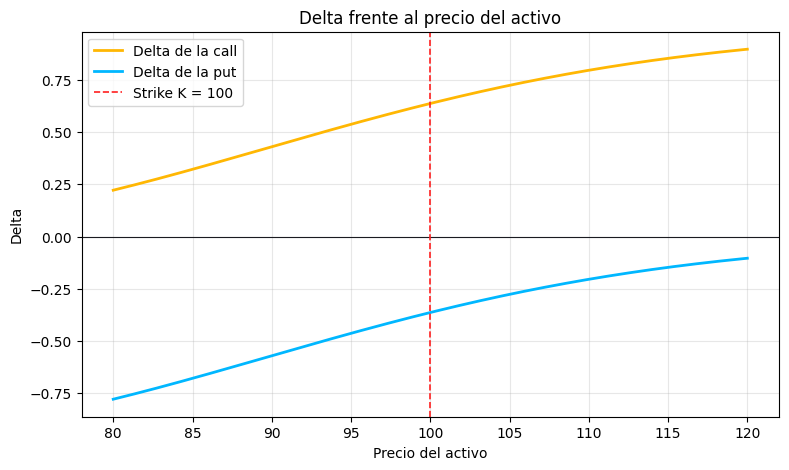

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(precios[:-1], delta_call, linewidth=2, color="#FFB703", label="Delta de la call")
plt.plot(precios[:-1], delta_put, linewidth=2, color="#00B7FF", label="Delta de la put")
plt.axhline(0, color="#1A1B21", linewidth=0.8)
plt.axvline(K, color="#FF2020", linestyle="--", linewidth=1.2, label=f"Strike K = {K}")

plt.title("Delta frente al precio del activo")
plt.xlabel("Precio del activo")
plt.ylabel("Delta")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La delta de la call crece de manera monótona entre cero y uno conforme el activo sube, alcanzando 0.636868 en el punto base contra los 0.636831 que entrega $N(d_1)$, y esa diferencia de 3.75 diezmilésimas no es ruido sin explicación, ya que el cociente de diferencias hacia adelante estima la pendiente en el punto medio del intervalo y ese corrimiento de medio paso multiplicado por la gamma local produce 0.018762 por 0.002, es decir, exactamente la brecha observada.

La delta de la put vale −0.363132 en el mismo punto, y la relación $\Delta_{call} - \Delta_{put} = 1$ se sostiene en toda la malla con una desviación máxima de 9.77e-12, resultado que confirma numéricamente una consecuencia de la paridad, pues derivar $C - P = S_0 - Ke^{-rT}$ respecto del activo deja la unidad del lado derecho.

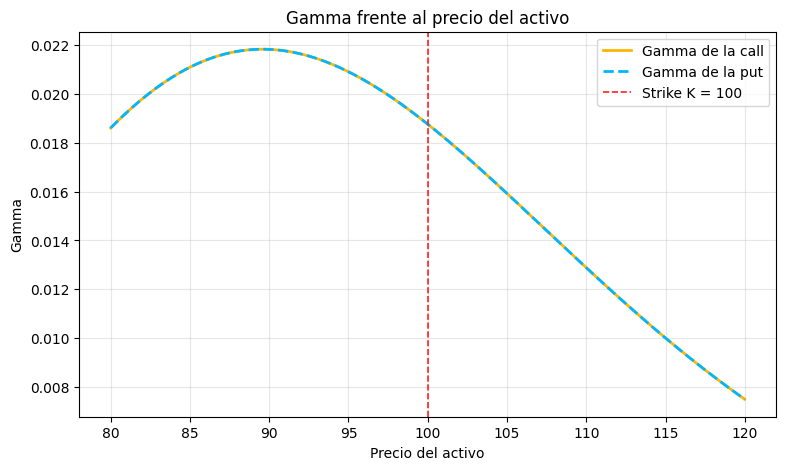

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(precios[:-2], gamma_call, linewidth=2, color="#FFB703", label="Gamma de la call")
plt.plot(precios[:-2], gamma_put, linewidth=2, color="#00B7FF", linestyle="--", label="Gamma de la put")
plt.axvline(K, color="#FF2020", linestyle="--", linewidth=1.2, label=f"Strike K = {K}")

plt.title("Gamma frente al precio del activo")
plt.xlabel("Precio del activo")
plt.ylabel("Gamma")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Gamma alcanza su máximo en la vecindad del strike, con 0.018760 en el punto base frente a los 0.018762 de la forma cerrada, y decae hacia cero en ambos extremos porque una opción muy dentro o muy fuera del dinero se comporta casi como una posición lineal, la primera porque su delta se aproxima a uno y la segunda porque se aproxima a cero, de modo que la curvatura sólo es relevante en la zona donde la delta todavía puede cambiar de forma brusca.

Las dos curvas se superponen y por ello la de la put se dibuja punteada, ya que la diferencia máxima entre ambas es de 4.22e-09, lo cual proviene de la misma relación de paridad, pues al derivar dos veces desaparece el término lineal y ambas opciones quedan con idéntica curvatura, con la consecuencia práctica de que una cartera cubierta en delta sigue expuesta a gamma sin importar cuál de los dos contratos se haya vendido.

## 3. Vega frente a la volatilidad

La volatilidad recorre el intervalo de 5% a 40% con un paso de 0.0001, elegido de nuevo para que el valor base de 20% quede sobre la malla, y el resto de los parámetros permanece en su nivel de referencia.

In [6]:
volatilidades = np.linspace(0.05, 0.40, 3501)

valores_call = []
valores_put = []

for volatilidad in volatilidades:
    d1 = (np.log(S_0 / K) + (r + 0.5 * volatilidad ** 2) * T) / (volatilidad * np.sqrt(T))
    d2 = d1 - volatilidad * np.sqrt(T)
    valores_call.append(S_0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2))
    valores_put.append(K * np.exp(-r * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

vega_call = []
vega_put = []

for k in range(len(volatilidades) - 1):
    paso = volatilidades[k + 1] - volatilidades[k]
    vega_call.append((valores_call[k + 1] - valores_call[k]) / paso)
    vega_put.append((valores_put[k + 1] - valores_put[k]) / paso)

vega_call = np.array(vega_call)
vega_put = np.array(vega_put)

posicion = 1500
vega_analitica = S_0 * norm.pdf(d1_base) * np.sqrt(T)

print(f"Vega en sigma = 0.20:            {vega_call[posicion]:.6f}")
print(f"Vega analítica S*phi(d1)*sqrt(T): {vega_analitica:.6f}")
print(f"Equivalente por cada punto porcentual de volatilidad: {vega_call[posicion] / 100:.6f}")
print(f"Máxima diferencia entre vega de call y de put: {np.max(np.abs(vega_call - vega_put)):.2e}")

Vega en sigma = 0.20:            37.524527
Vega analítica S*phi(d1)*sqrt(T): 37.524035
Equivalente por cada punto porcentual de volatilidad: 0.375245
Máxima diferencia entre vega de call y de put: 2.84e-10


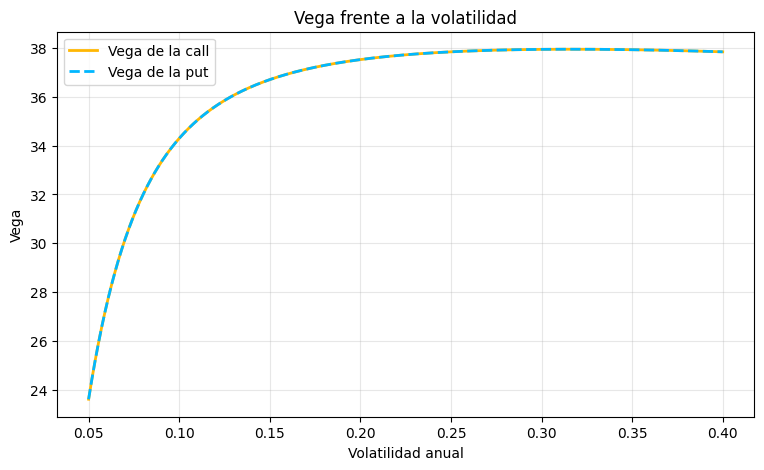

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(volatilidades[:-1], vega_call, linewidth=2, color="#FFB703", label="Vega de la call")
plt.plot(volatilidades[:-1], vega_put, linewidth=2, color="#00B7FF", linestyle="--", label="Vega de la put")

plt.title("Vega frente a la volatilidad")
plt.xlabel("Volatilidad anual")
plt.ylabel("Vega")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Vega vale 37.524527 en la volatilidad base contra los 37.524035 de la forma cerrada, cifra que conviene traducir a la escala en que se utiliza, ya que dividida entre cien indica que un punto porcentual adicional de volatilidad encarece la opción en 0.375 pesos, y de nuevo la coincidencia entre call y put es total, con una diferencia máxima de 2.84e-10 que justifica dibujar punteada la segunda curva.

La forma de la curva matiza el resultado del análisis de sensibilidad anterior, donde el precio parecía crecer de manera casi lineal con la volatilidad, pues aquí se observa que vega sube de 23.592271 en 5% hasta un máximo de 37.948564 y después desciende ligeramente hasta 37.841983 en 40%, de modo que la relación no es lineal sino cóncava en su tramo alto.

El punto donde se alcanza ese máximo no es casual, ya que ocurre en una volatilidad de 31.62% y coincide con $\sqrt{2r} = 0.3162$, valor en el que $d_1$ toma su mínimo y la densidad normal alcanza su punto más alto, con lo cual la sensibilidad a la incertidumbre deja de crecer precisamente cuando la opción alcanza su mayor grado de indeterminación sobre el resultado final.

## 4. Theta frente al tiempo

El plazo recorre el intervalo de 0.25 a 2 años con un paso de 0.0001, y conviene fijar desde ahora la convención de signo, ya que aquí se calcula $\partial V/\partial T$ tal como se planteó el ejercicio, mientras que la theta que se reporta en el mercado lleva signo contrario porque mide el efecto del calendario sobre un plazo que se acorta día con día.

In [8]:
plazos = np.linspace(0.25, 2, 17501)

valores_call = []
valores_put = []

for plazo in plazos:
    d1 = (np.log(S_0 / K) + (r + 0.5 * sigma ** 2) * plazo) / (sigma * np.sqrt(plazo))
    d2 = d1 - sigma * np.sqrt(plazo)
    valores_call.append(S_0 * norm.cdf(d1) - K * np.exp(-r * plazo) * norm.cdf(d2))
    valores_put.append(K * np.exp(-r * plazo) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

theta_call = []
theta_put = []

for k in range(len(plazos) - 1):
    paso = plazos[k + 1] - plazos[k]
    theta_call.append((valores_call[k + 1] - valores_call[k]) / paso)
    theta_put.append((valores_put[k + 1] - valores_put[k]) / paso)

theta_call = np.array(theta_call)
theta_put = np.array(theta_put)

posicion = 7500
d2_base = d1_base - sigma * np.sqrt(T)
theta_call_analitica = (S_0 * norm.pdf(d1_base) * sigma / (2 * np.sqrt(T))
                        + r * K * np.exp(-r * T) * norm.cdf(d2_base))
theta_put_analitica = (S_0 * norm.pdf(d1_base) * sigma / (2 * np.sqrt(T))
                       - r * K * np.exp(-r * T) * norm.cdf(-d2_base))

print(f"Theta de la call en T = 1: {theta_call[posicion]:.6f}")
print(f"Theta analítica de la call: {theta_call_analitica:.6f}")
print(f"Theta de la put en T = 1:  {theta_put[posicion]:.6f}")
print(f"Theta analítica de la put:  {theta_put_analitica:.6f}")
print(f"Theta de la put en T = 2:  {theta_put[-1]:.6f}")

Theta de la call en T = 1: 6.413923
Theta analítica de la call: 6.414028
Theta de la put en T = 1:  1.657787
Theta analítica de la put:  1.657880
Theta de la put en T = 2:  0.613668


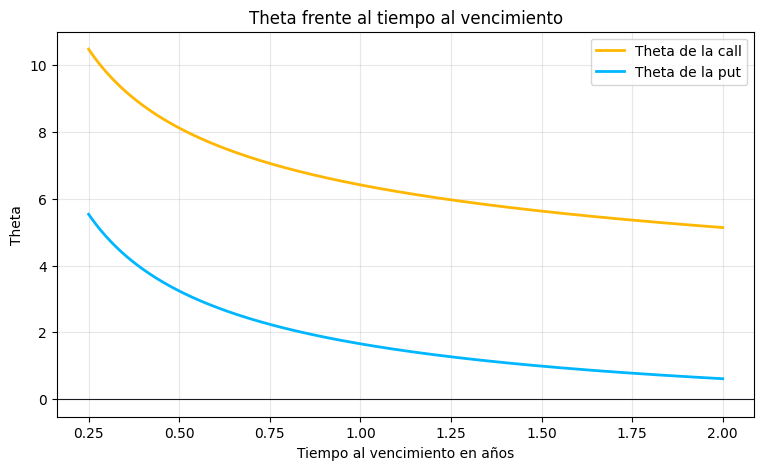

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(plazos[:-1], theta_call, linewidth=2, color="#FFB703", label="Theta de la call")
plt.plot(plazos[:-1], theta_put, linewidth=2, color="#00B7FF", label="Theta de la put")
plt.axhline(0, color="#1A1B21", linewidth=0.8)

plt.title("Theta frente al tiempo al vencimiento")
plt.xlabel("Tiempo al vencimiento en años")
plt.ylabel("Theta")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Theta desciende de forma monótona en ambos contratos, ya que la call pasa de 10.474151 en 0.25 años a 5.137825 en 2 años y la put recorre un trayecto mucho más pronunciado al caer de 5.536262 a 0.613668, con 6.413923 y 1.657787 respectivamente en el plazo base, valores que reproducen la forma cerrada hasta la tercera cifra decimal.

Esa caída explica con precisión un resultado que en el análisis de sensibilidad quedó sólo descrito, pues ahí se observó que el valor de la put avanzaba apenas 21.62% entre el primer y el segundo año, y aquí se ve la razón, ya que su derivada respecto del plazo se reduce a 0.613668 hacia el final del rango, es decir, el plazo adicional casi deja de aportar valor porque la ganancia por mayor dispersión se compensa con el descuento creciente del strike.

Conviene subrayar que ambas derivadas se mantienen positivas en todo el intervalo, lo cual no contradice la noción de que el tiempo erosiona el valor de una opción, ya que aquí se derivó respecto del plazo restante y la theta de mercado invierte el signo al medir el efecto del calendario, de modo que un comprador enfrenta una theta negativa de 6.413923 pesos por año en el punto base.

## 5. Rho frente a la tasa

La tasa libre de riesgo recorre el intervalo de 5% a 40% con un paso de 0.0001, rango deliberadamente amplio que permite observar la curvatura completa de rho aunque los niveles superiores queden lejos de cualquier escenario realista.

In [10]:
tasas = np.linspace(0.05, 0.40, 3501)

valores_call = []
valores_put = []

for tasa in tasas:
    d1 = (np.log(S_0 / K) + (tasa + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    valores_call.append(S_0 * norm.cdf(d1) - K * np.exp(-tasa * T) * norm.cdf(d2))
    valores_put.append(K * np.exp(-tasa * T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1))

rho_call = []
rho_put = []

for k in range(len(tasas) - 1):
    paso = tasas[k + 1] - tasas[k]
    rho_call.append((valores_call[k + 1] - valores_call[k]) / paso)
    rho_put.append((valores_put[k + 1] - valores_put[k]) / paso)

rho_call = np.array(rho_call)
rho_put = np.array(rho_put)

rho_call_analitica = K * T * np.exp(-r * T) * norm.cdf(d2_base)
rho_put_analitica = -K * T * np.exp(-r * T) * norm.cdf(-d2_base)

print(f"Rho de la call en r = 0.05: {rho_call[0]:.6f}")
print(f"Rho analítica de la call:    {rho_call_analitica:.6f}")
print(f"Rho de la put en r = 0.05:  {rho_put[0]:.6f}")
print(f"Rho analítica de la put:     {rho_put_analitica:.6f}")
print(f"Equivalente por cada punto porcentual de tasa: {rho_call[0] / 100:.6f}")

Rho de la call en r = 0.05: 53.239200
Rho analítica de la call:    53.232482
Rho de la put en r = 0.05:  -41.878986
Rho analítica de la put:     -41.890461
Equivalente por cada punto porcentual de tasa: 0.532392


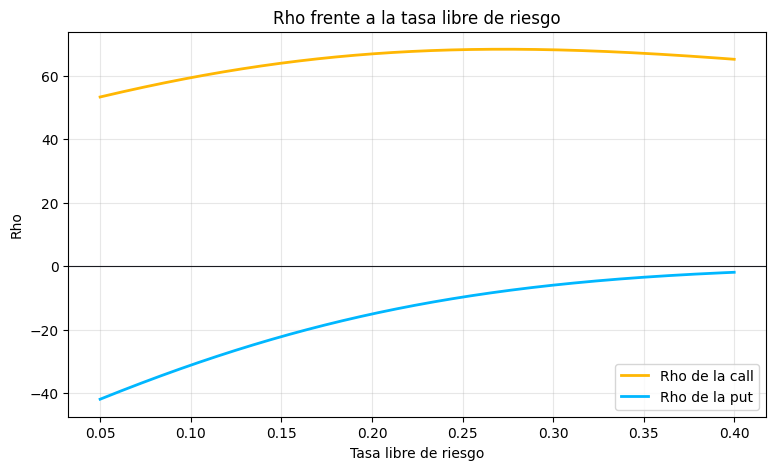

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(tasas[:-1], rho_call, linewidth=2, color="#FFB703", label="Rho de la call")
plt.plot(tasas[:-1], rho_put, linewidth=2, color="#00B7FF", label="Rho de la put")
plt.axhline(0, color="#1A1B21", linewidth=0.8)

plt.title("Rho frente a la tasa libre de riesgo")
plt.xlabel("Tasa libre de riesgo")
plt.ylabel("Rho")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Rho vale 53.239200 para la call y −41.878986 para la put en la tasa base, cifras que equivalen a 0.532392 y −0.418790 pesos por cada punto porcentual, y el contraste de signos confirma lo observado en el análisis de sensibilidad, ya que una tasa más alta desplaza la distribución del activo hacia arriba y abarata el strike en valor presente, lo cual favorece a la call y perjudica a la put.

Las dos curvas revelan un comportamiento que la tabulación gruesa no dejaba ver, pues rho de la call no crece de manera indefinida sino que alcanza un máximo de 68.274924 en una tasa de 27.29% y después desciende hasta 65.107076 en 40%, mientras rho de la put se acerca a cero desde abajo hasta −1.924929, y ambos efectos tienen el mismo origen, ya que a tasas muy altas la call termina prácticamente segura de ejercerse y la put prácticamente segura de expirar sin valor, con lo cual la sensibilidad adicional se agota.

Rho es también la griega donde el método numérico pierde más precisión, pues la call se desvía 0.006718 pesos de su forma cerrada y la put 0.011475, cifras muy superiores a las de las otras cuatro derivadas, y la razón no está en el paso de la malla sino en la curvatura de la función, ya que el sesgo de una diferencia hacia adelante equivale a la segunda derivada multiplicada por medio paso, y respecto de la tasa esa segunda derivada supera doscientos en el caso de la put.

## 6. Tabla de efectos

El conjunto de resultados se resume en la relación entre cada variable, la dirección en que mueve a cada contrato y la griega que mide esa respuesta.

| Variable | Efecto en la call | Efecto en la put | Griega asociada |
|---|---|---|---|
| $S \in [80, 120]$ | Sube | Baja | Delta y gamma |
| $\sigma \in [5, 40]\%$ | Sube | Sube | Vega |
| $T \in [0.25, 2]$ | Sube | Sube | Theta |
| $r \in [5, 40]\%$ | Sube | Baja | Rho |

La lectura por renglones deja ver que sólo la volatilidad y el plazo empujan a los dos contratos en la misma dirección, y la lectura por columnas agrega una distinción que las derivadas hacen evidente, ya que delta y rho tienen signo opuesto entre call y put mientras gamma y vega son numéricamente idénticas para ambas, de modo que una posición que combine los dos contratos puede neutralizar el precio del activo y la tasa, pero nunca la curvatura ni la exposición a la volatilidad.

## 7. Conclusiones

El método de diferencias finitas reproduce las cinco derivadas con una precisión que vuelve innecesaria la forma cerrada para fines de análisis, ya que delta, gamma, vega, theta y rho coinciden con sus expresiones analíticas con un error relativo inferior a 0.03% en el peor de los casos, es decir, con al menos cuatro cifras significativas correctas, y ese peor caso corresponde a rho de la put mientras que el más limpio es vega, con 1.3 partes por millón de discrepancia.

El origen del sesgo es el mismo en las cinco y admite una comprobación directa, ya que la diferencia hacia adelante mide la pendiente en el punto medio del intervalo y no en su extremo, de modo que el error debe equivaler a la segunda derivada multiplicada por medio paso, y en el caso de la delta ese producto da 0.018762 por 0.002, exactamente las 3.75 diezmilésimas observadas.

Las identidades estructurales del modelo aparecen sin haberlas impuesto, pues la delta de la call menos la de la put da uno con una desviación de 9.77e-12, la gamma de ambos contratos coincide dentro de 4.22e-09 y la vega dentro de 2.84e-10, y esas tres coincidencias no son propiedades independientes sino consecuencias de derivar la paridad put-call una y dos veces, con lo cual el cálculo numérico funciona además como verificación de la consistencia interna del esquema.

El valor agregado frente al análisis de sensibilidad previo está en los máximos interiores, ya que ahí las curvas de precio parecían crecer de forma sostenida y aquí se descubre que la sensibilidad se agota, con vega alcanzando su punto más alto en una volatilidad de 31.62% que coincide con $\sqrt{2r}$ y rho haciéndolo en una tasa de 27.29%, mientras la theta de la put desciende de 5.536262 a 0.613668 y explica numéricamente el aplanamiento que antes sólo se había descrito.

El principal límite del procedimiento es que la diferencia hacia adelante es de primer orden y arrastra un sesgo proporcional al paso, por lo cual la mejora inmediata consiste en sustituirla por una diferencia centrada que cancela ese término sin costo adicional de cómputo, y conviene recordar que la valuación se tomó de la fórmula analítica precisamente porque el estimador Monte Carlo con muestra compartida es lineal por tramos y su segunda derivada resultaría inservible, de manera que cualquier extensión hacia griegas simuladas exige técnicas distintas como la diferenciación de la trayectoria o el método del cociente de verosimilitudes.